# N2 + H2O (gas, condensate)

Hajime Kawahara 2025/11/16

In this notebook, we adopt N2 as the background atmosphere and water as a species that can exist either in the gas phase or as a condensate. We then examine how the phase of water is determined through Gibbs free‐energy minimization.

In [1]:
from jax import config
config.update("jax_enable_x64", True)

We assume N2+H2O (gas, water, ice) system using fastchem/fastchem_cond presets. 

In [2]:
from exogibbs.presets.fastchem_cond import chemsetup as condsetup
cond = condsetup()
from exogibbs.presets.fastchem import chemsetup as gassetup
gas = gassetup()


fastchem_cond presets in ExoGibbs
number of species: 186 elements: 28 molecules: 186
fastchem presets in ExoGibbs
number of species: 523 elements: 28 molecules: 495


In [3]:
gas_species = list(gas.species)
gas_system = ['H2O1', 'N2']
index_h2o_gas = gas_species.index('H2O1')  
index_n2_gas = gas_species.index('N2')

cond_species = list(cond.species)
cond_system = ['H2O(s,l)']
index_h2o_cond = cond_species.index('H2O(s,l)')  

In [4]:
from exogibbs.thermo.stoichiometry import build_formula_matrix
from exogibbs.utils.nameparser import set_elements_from_components
from exogibbs.utils.nameparser import generate_components_from_formula_list

components_g = generate_components_from_formula_list(gas_system)
elements = set_elements_from_components(components_g)
formula_matrix_gas = build_formula_matrix(components_g, elements)

print("Formula matrix (gas):")
print(formula_matrix_gas)

components_c = generate_components_from_formula_list(cond_system)
formula_matrix_cond = build_formula_matrix(components_c, elements)

print("Formula matrix (cond):")
print(formula_matrix_cond)



Formula matrix (gas):
[[0 2]
 [2 0]
 [1 0]]
Formula matrix (cond):
[[0]
 [2]
 [1]]


Output the reference-state value of ( $h = \mu / (RT)$ ) at temperature ( T ).


In [5]:
def h2o_cond_h_values(T): 
    return  cond.hvector_func(T)[index_h2o_cond]

def h2o_gas_h_values(T):
    return  gas.hvector_func(T)[index_h2o_gas]

def n2_gas_h_values(T):
    return  gas.hvector_func(T)[index_n2_gas]

In [6]:
import numpy as np
def gibbs_energy(m, n, nn2, p, T):
    ntot = n + nn2
    mu_h2o = h2o_gas_h_values(T) + np.log(p*n/ntot)
    mu_n2 = n2_gas_h_values(T) + np.log(p*nn2/ntot)
    return h2o_cond_h_values(T)*m + mu_h2o*n + mu_n2*nn2

In [7]:
nh2o = 0.1

def gibbs_given(m,T,p=1.0):
    return gibbs_energy(m, nh2o-m, 1.0 - nh2o, p, T)

In [8]:
import matplotlib.pyplot as plt

/tmp/ipykernel_16364/2701145478.py:4: RuntimeWarning: divide by zero encountered in log
  mu_h2o = h2o_gas_h_values(T) + np.log(p*n/ntot)


Text(0.5, 0, 'condensate fraction')

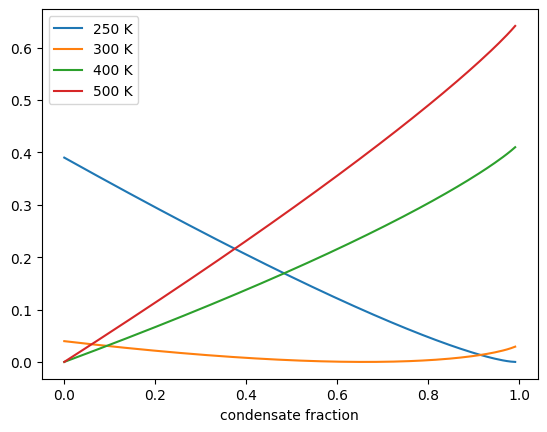

In [9]:
marr = np.logspace(-5,np.log10(nh2o),1000)
for T in [250,300,400,500]:
    plt.plot(marr/nh2o, gibbs_given(marr,T) - np.nanmin(gibbs_given(marr,T)), label=str(T)+" K")
plt.legend()
plt.xlabel("condensate fraction")
#plt.xscale("log")

In [10]:
def mmin(T,p=1.0):
    i = np.nanargmin(gibbs_given(marr,T,p))
    return marr[i]

/tmp/ipykernel_16364/2701145478.py:4: RuntimeWarning: divide by zero encountered in log
  mu_h2o = h2o_gas_h_values(T) + np.log(p*n/ntot)
100%|██████████| 150/150 [00:33<00:00,  4.49it/s]


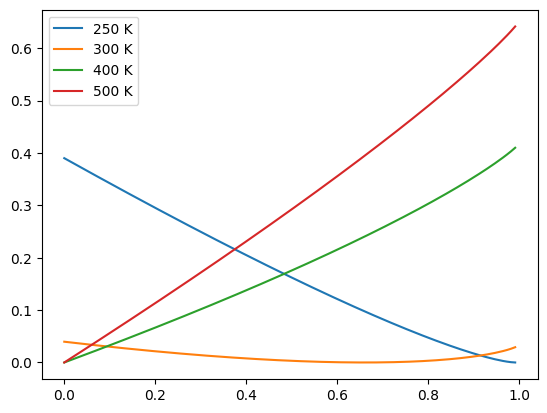

In [14]:
from tqdm import tqdm
Parr = np.logspace(-3,3,150)
for T in [250,300,400,500]:
    plt.plot(marr/nh2o, gibbs_given(marr,T) - np.nanmin(gibbs_given(marr,T)), label=str(T)+" K")
plt.legend()
Tarr = np.linspace(100,500,150)

mastarr = []
for p in tqdm(Parr):
    mastarr_t = []
    for T in Tarr:
        mastarr_t.append(mmin(T,p))
    mastarr.append(mastarr_t)
mastarr = np.array(mastarr)

In [15]:
from exojax.atm.psat import psat_water_AM01 
Psat_arr = psat_water_AM01(Tarr)

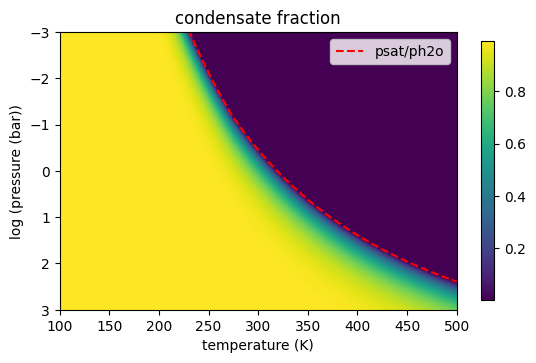

In [16]:
fig = plt.figure()
ax = fig.add_subplot(111)
c = ax.imshow(mastarr/nh2o, extent=(Tarr[0],Tarr[-1],np.log10(Parr[-1]),np.log10(Parr[0])))
plt.plot(Tarr, np.log10(Psat_arr/nh2o), color='red', linestyle='dashed', label='psat/ph2o')
ax.set_ylim(np.log10(Parr[0]), np.log10(Parr[-1]))
plt.colorbar(c, shrink=0.7)
ax.set_aspect(0.7/ax.get_data_ratio())
plt.gca().invert_yaxis()
ax.set_xlabel("temperature (K)")
ax.set_ylabel("log (pressure (bar))")
ax.set_title("condensate fraction")
plt.legend()
plt.show()

In this way, we see that minimizing the Gibbs energy of an ideal gas together with a condensate does not yield a discontinuous transition. Instead, the solution provides an approximation in which the transition occurs continuously over a narrow region near the condensation curve.